### Convolutional Neural Network 
#### Use MNIST Fashion Dataset and create a classifier to classify fashion clothing into categories

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [45]:
# Import the fashion_mnist dataset
from tensorflow.keras.datasets import fashion_mnist

print(fashion_mnist)

<module 'keras.api.datasets.fashion_mnist' from 'C:\\Users\\saksh\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages\\keras\\api\\datasets\\fashion_mnist\\__init__.py'>


In [46]:
# Split the dataset into train and test
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [50]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.losses import sparse_categorical_crossentropy

# A CNN model with the following layers:
model = Sequential()

model.add(Conv2D(128, kernel_size=(3,3), activation='relu'))  # Detect image features
model.add(MaxPooling2D())  # Reduce image size
model.add(Flatten())    # Convert 2D → 1D   
model.add(Dropout(0.2))  # Reduce overfitting

# Add Dense Layers - Fully connected neural layer 
model.add(Dense(128, activation='relu'))

# Output Layer - 10 neurons
model.add(Dense(10, activation='softmax'))


In [ ]:
# Compile
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [24]:
# Trains the CNN on the training data for 5 epochs.

model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 38ms/step - accuracy: 0.8144 - loss: 3.5135  
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.8926 - loss: 0.2950 
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9032 - loss: 0.2581 
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 36ms/step - accuracy: 0.9094 - loss: 0.2400 
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step - accuracy: 0.9167 - loss: 0.2235 


In [26]:
# Evaluate the model
metrics = model.evaluate(x_test, y_test)
metrics

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8890 - loss: 0.3469


[0.3400307297706604, 0.88919997215271]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Predicted: Shirt
Actual: Shirt
Correct Label Predicted


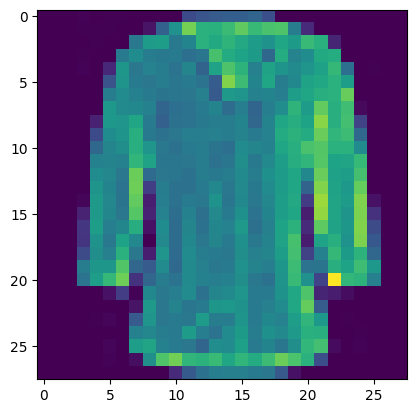

In [31]:
# Predicts label for 5th test image (image_index = 4)
image_index = 4
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

prediction = model.predict(x_test[image_index:image_index+1])
predicted_label = np.argmax(prediction)
true_label = y_test[image_index]

print(f"Predicted: {class_names[predicted_label]}")
print(f"Actual: {class_names[true_label]}")


# Compares it with actual label and prints result.
if np.argmax(prediction) == y_test[image_index]:
    print("Correct Label Predicted")
else:
    print("Incorrect Label Predicted")


# Displays the image using imshow
plt.imshow(x_test[image_index:image_index+1][0])